In [1]:
import os
import psycopg2
import sqlalchemy
import numpy as np
import pandas as pd
import urllib.request
import seaborn as sns
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sqlalchemy import create_engine,URL
pd.set_option('display.max_columns',40)
pd.set_option('display.float_format','{:.2f}'.format)
load_dotenv();

We prioritize security and reproducibility by managing database credentials using environment variables (.env file) and the python-dotenv library. This allows us to access the PostgreSQL host, user, and password securely without hardcoding them into the notebook, which is a critical best practice for version control and collaborative projects. The PostgresClient class is initialized using the sqlalchemy.create_engine pattern, abstracting the connection logic and ensuring that all subsequent database interactions are handled robustly and efficiently.

In [2]:
"""  The data we are going to use is hosted on Github. The supermarket chips dataset has two files- purchase & transaction data in CSV and XLSX format
respectively.We'll use some custom python code to extract this content into pandas dataframe.

Additionally, we are going to:
1. Convert the Date column into a proper datetime format.
2. Review the raw structure using .head(), .shape(), .describe(), and .info()
3. Ensure all text fields (e.g., Country, Description) are correctly typed as string/object.
"""
files = ['https://raw.githubusercontent.com/bellonbits/Supermarket-Chips-Sales-Dataset/main/QVI_purchase_behaviour%20(1).csv',
         'https://raw.githubusercontent.com/bellonbits/Supermarket-Chips-Sales-Dataset/main/QVI_transaction_data%20(1).xlsx']

def extract_files(url, filename):
    """
    Download and save files locally from gitHub.
    Return: pandas.DataFrame: DataFrame containing the contents of the
    meber file in files list. We'll perform date conversions from excel format to pandas date time.
    """
    os.makedirs('data', exist_ok=True)
    filepath = os.path.join('data', filename)
    fin = urllib.request.urlopen(url)
    data = fin.read() 
    with open(filepath, mode='wb') as fout:
        fout.write(data)
        print(f"Success. File name {filename} saved")
    return pd.read_csv(filepath) if filename.endswith('.csv') else (pd.read_excel(filepath)
                                                                    #convert date column into proper datetime format
                                                                    .assign(DATE = lambda df_ : pd.to_datetime(df_['DATE'], unit='D', origin='1899-12-30'))
                                                                    )

In [3]:
#download purchase data and load into pandas dataframe
purchase_df  = extract_files(files[0], 'purchase_behaviour.csv')
purchase_df.head(2)

Success. File name purchase_behaviour.csv saved


,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream


In [4]:
transaction_df  = extract_files(files[1], 'transaction_data.xlsx')
transaction_df.head(2)

Success. File name transaction_data.xlsx saved


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.00
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.30


### DATA STORAGE (Database & SQL Layer)
- Main goal here is to store structured data in a relational database for secure and scalable use.
- Create a streamlined re-usable class that automatically creates a database engine using environment variables for configurations.

*Steps:* 
1. Use os.getenv() to securely load database credentials from environment variables.
2. Leverage SQLAlchemy's create_engine() and URL.create() for database connection management and URL construction.
3. Integrate pandas' to_sql() and read_sql() methods for seamless DataFrame-to-database operations.
4. Use PostgreSQL adapter (psycopg2) to establish the actual database connection.
5. Close the resources gracefully.

In [ ]:
#Create a custom postgress client
class PostgresClient:
    """ The imported, raw transaction and customer dataframes must first be persisted to a structured database to allow for reproducible analysis and to handle large data volumes efficiently. 
     The PostgresClient.insert_dataframe method is used to load these Pandas DataFrames directly into a new table in PostgreSQL. We will initially rely on the database's inferred column types.
     However, for a production-ready setup, we would define a precise dtype_map to explicitly set database column types (e.g., VARCHAR(100), DATE, NUMERIC(10, 2)).
     This guarantees data integrity and optimizes query performance for all subsequent analytical steps."""
    def __init__(self):
        self.engine = self._get_db_engine()

    def _get_db_engine(self):
        connection_url = URL.create(
            drivername = 'postgresql',
            username = os.getenv('DB_USER'),
            host = os.getenv('DB_HOST'),
            port = os.getenv('DB_PORT'),
            password = os.getenv('DB_PASSWORD'),
            database = os.getenv('DB_NAME')
            )
        return create_engine(connection_url)
    
    def insert_dataframe(self,
            df,
            schema,
            table_name,
            if_exists = 'replace',
            index = False,
            dtype_map = None):
         with self.engine.connect() as connection:
             with connection.begin():
                 try:
                     df.to_sql(con =connection,
                         schema = schema,
                         name = table_name,
                         if_exists = if_exists,
                         index =index,
                         dtype = dtype_map)
                     print(f"Success. Inserted {len(df)} records into {table_name} table")
                 except Exception as e:
                     print(f"An error occured: {e}")
                     raise
    def select_data(self, sql_query):
        with self.engine.connect() as connection:
            try:
                result_df = pd.read_sql(sql_query, connection)
                print(f"Query successful. Fetched {len(result_df)} rows.")
                return result_df
                
            except Exception as e:
                print(f"An Error occured: {e}")
                return pd.DataFrame()

In [6]:
#Initialize the class instance
db_manager = PostgresClient()

We are going to streamline batch database ingestion by defining multiple DataFrame to table mappings in a structured way.
The code batch-inserts two DataFrames one with purchase behavior data and another with transaction data - into a PostgreSQL database (already set up) under the *cust_data schema*, using a configuration list to map each dataset to its respective table (purchase_behaviour and transaction_data). It will employ the initialized db_manager (above) to handle the insertion, replacing any existing tables with the new data (if_exists='replace'). The list comprehension iterates over the configs and executing each insertion sequentially to load both tables in one streamlined operation. We shall handle explicit dtypes insertion later on.

In [7]:
configs = [
    {
        'df': purchase_df,
        'schema': 'cust_data',
        'table_name': 'purchase_behaviour',
        'dtype_map': None  # To do, define dtypes i.e., {'PROD_NAME': 'VARCHAR(100)'} in prod.
    },
    {
        'df': transaction_df,
        'schema': 'cust_data',
        'table_name': 'transaction_data',
        'dtype_map': None
    }
]
[db_manager.insert_dataframe(
    config['df'],
    config['schema'],
    config['table_name'],
    if_exists='replace',
    index=False,
    dtype_map=config['dtype_map']
) for config in configs];

Success. Inserted 72637 records into purchase_behaviour table
Success. Inserted 264836 records into transaction_data table


Rather than performing extensive cleaning, feature engineering, and table joining directly in memory, we leverage the database's power. By storing the raw, cleaned, and merged dataframes in PostgreSQL, we can retrieve them instantly using efficient SQL queries via the postgres_client.query_to_dataframe method. 

This allows us to:
1. **Reduce Memory Footprint**- Analysis relies on querying the database and not loading the entire raw dataset into the Jupyter Notebook's memory.
2. **Ensure Consistency**- Analytical steps start from the exact same persistent, cleaned, and merged data source within the database.
3. **Future-Proofing**- Structure is scalable making it easy to integrate the current analysis into a larger data pipeline or dashboarding tool (like Power BI or Tableau) down the line.

In [8]:
#Load transaction data from postgress into pandas
sql_Tran_Data = """
select * from cust_data.transaction_data
"""
transaction_rslt = db_manager.select_data(sql_Tran_Data)
transaction_rslt.head(3)

Query successful. Fetched 264836 rows.


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.00
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.30
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.90


In [9]:
#Load purchase data from postgress into pandas
sql_Purchse_Data = """
select * from cust_data.purchase_behaviour
"""
purchase_rslt = db_manager.select_data(sql_Purchse_Data)
purchase_rslt.head(3)

Query successful. Fetched 72637 rows.


,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget


### DATA PREPARATION (Cleaning & Transformation)
*Goal: Prepare clean, accurate, analysis-ready data for downstream use.*
Steps:
1. Merge transaction and purchase data
2. Check for missing values
3. Identify and remove duplicates
4. Correct data types (e.g., convert DATE to datetime, ensure TOT_SALES is numeric)
5. Engineer new useful fields such as:
    - Month of purchase
    - Year
    - Brand extracted from PROD_NAME
    - Pack size extracted from PROD_NAME
6. Remove invalid or corrupted transaction records, such as negative totals or zero quantity.


In [10]:
#Data preparation to merge two dataframes and inspect data using info()
#Use memory_usage='deep' to include Python objects in the DataFrame's memory calculation.
combined_df = (transaction_rslt
 .merge(purchase_rslt,
         how = 'left', left_on = ['LYLTY_CARD_NBR'], right_on = ['LYLTY_CARD_NBR'])
 )
combined_df.info(memory_usage ='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              264836 non-null  datetime64[ns]
 1   STORE_NBR         264836 non-null  int64         
 2   LYLTY_CARD_NBR    264836 non-null  int64         
 3   TXN_ID            264836 non-null  int64         
 4   PROD_NBR          264836 non-null  int64         
 5   PROD_NAME         264836 non-null  object        
 6   PROD_QTY          264836 non-null  int64         
 7   TOT_SALES         264836 non-null  float64       
 8   LIFESTAGE         264836 non-null  object        
 9   PREMIUM_CUSTOMER  264836 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(5), object(3)
memory usage: 65.7 MB


In [11]:
#Create a DataFrame showing the count and percentage of missing values for each column.
(combined_df
    .isna()
    .sum()
    .to_frame('missing_count')
    .assign(missing_percentage=lambda df_: (df_.missing_count / len(combined_df) * 100).round(2),
        total_rows =  len(combined_df))
        
    .sort_values('missing_percentage', ascending=False)
)

,missing_count,missing_percentage,total_rows
DATE,0,0.00,264836
STORE_NBR,0,0.00,264836
LYLTY_CARD_NBR,0,0.00,264836
TXN_ID,0,0.00,264836
PROD_NBR,0,0.00,264836
PROD_NAME,0,0.00,264836
PROD_QTY,0,0.00,264836
TOT_SALES,0,0.00,264836
LIFESTAGE,0,0.00,264836
PREMIUM_CUSTOMER,0,0.00,264836


In [12]:
#shape method is essential in method chaining to inspect intermediate dataframes. 
# This helps prevent accidental data loss (rows being removed)  or a combinatory explosion of data following a merge operation.
# Our data still intact after merge --> 264836 rows × 10 columns
def shape(df_):
    print(df_.shape)
    return df_
shape(combined_df)

(264836, 10)


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.00,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.30,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.90,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.00,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.80,MIDAGE SINGLES/COUPLES,Budget
...,...,...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.80,YOUNG SINGLES/COUPLES,Premium
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.40,YOUNG SINGLES/COUPLES,Premium
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.80,YOUNG SINGLES/COUPLES,Premium
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.80,YOUNG SINGLES/COUPLES,Premium


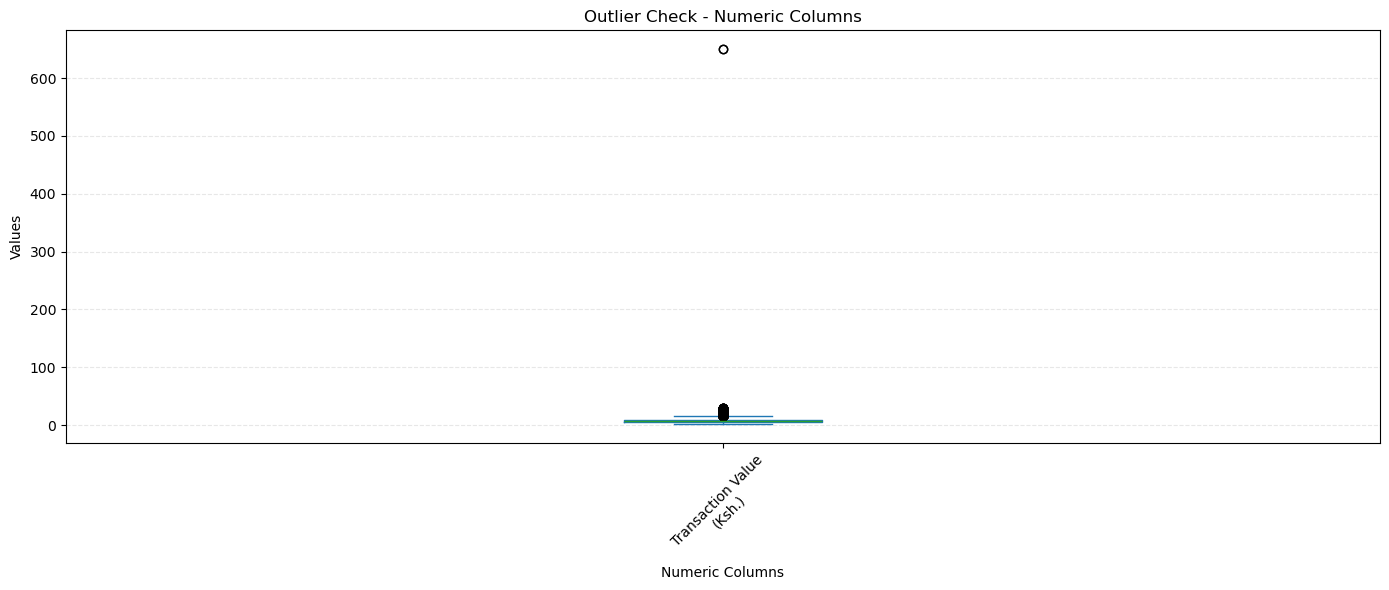

In [13]:
#Outlier Detection  on numeric columns  - Total sales
fig, ax = plt.subplots(figsize=(14, 6))

(combined_df
 #.loc[:,['TOT_SALES', 'PROD_QTY', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR']]
 .loc[:,['TOT_SALES']]
 .rename(columns={'TOT_SALES': 'Transaction Value\n(Ksh.)','PROD_QTY': 'Product\nQuantity','STORE_NBR': 'Store\nNumber', 
                  'LYLTY_CARD_NBR': 'Loyalty\nCard','TXN_ID': 'Transaction\nID', 'PROD_NBR': 'Product\nNumber' })
 .plot
 .box(ax=ax, vert=True)
 .set(title='Outlier Check - Numeric Columns',
      xlabel='Numeric Columns',
      ylabel='Values')
)

(ax.yaxis
 .set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
)

ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.tight_layout()
plt.show()

In [14]:
"""
Extreme outliers are present in the transaction data. 
Most significant anomaly is a single , customer card number 226000, who purchased 200 packets of Dorino Corn chips on two occassions - each single tranasction.
While rare, these outliers inflated the perceived average transaction value. 
"""
(combined_df
.query('TOT_SALES > 600')
 )

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.00,OLDER FAMILIES,Premium
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.00,OLDER FAMILIES,Premium


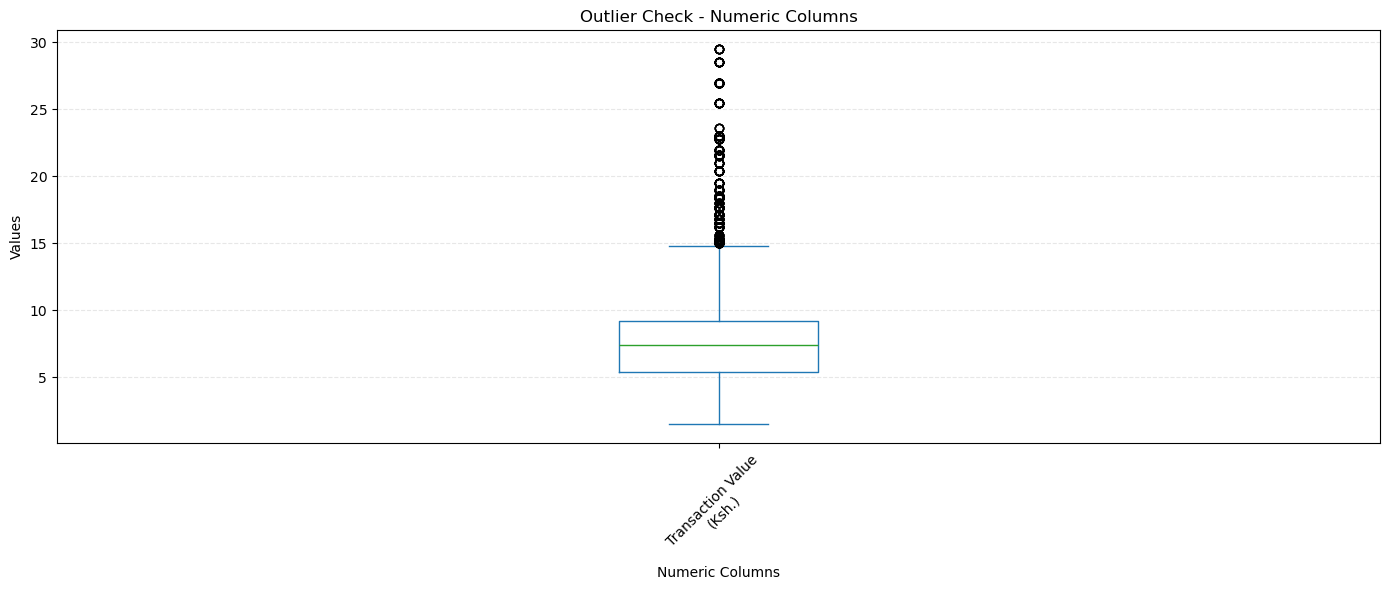

In [15]:
"""
After identifying and removing these anomalies (such as the 200-pack transaction),
the filtered data revealed the true core retail pattern:

1. 95% + of all transactions fall below Ksh 30.
2. The box (interquartile range) sits between approximately Ksh 6-9. 
3. The median (green line) is around Ksh 7-8.
4. There's a massive cluster of outliers above the upper whisker ranging from about Ksh 15 to 30
   which also represent transactions that are substantially higher than the typical range.
5. The whiskers extend to roughly Ksh 2-15 showing the "normal" range of data.
"""
fig, ax = plt.subplots(figsize=(14, 6))

(combined_df
 #.loc[:,['TOT_SALES', 'PROD_QTY', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR']]
 .loc[:,['TOT_SALES']]
.query('TOT_SALES <600')
 .rename(columns={'TOT_SALES': 'Transaction Value\n(Ksh.)'})
 .plot
 .box(ax=ax, vert=True)
 .set(title='Outlier Check - Numeric Columns',
      xlabel='Numeric Columns',
      ylabel='Values')
)

(ax.yaxis
 .set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
)

ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.tight_layout()
plt.show()

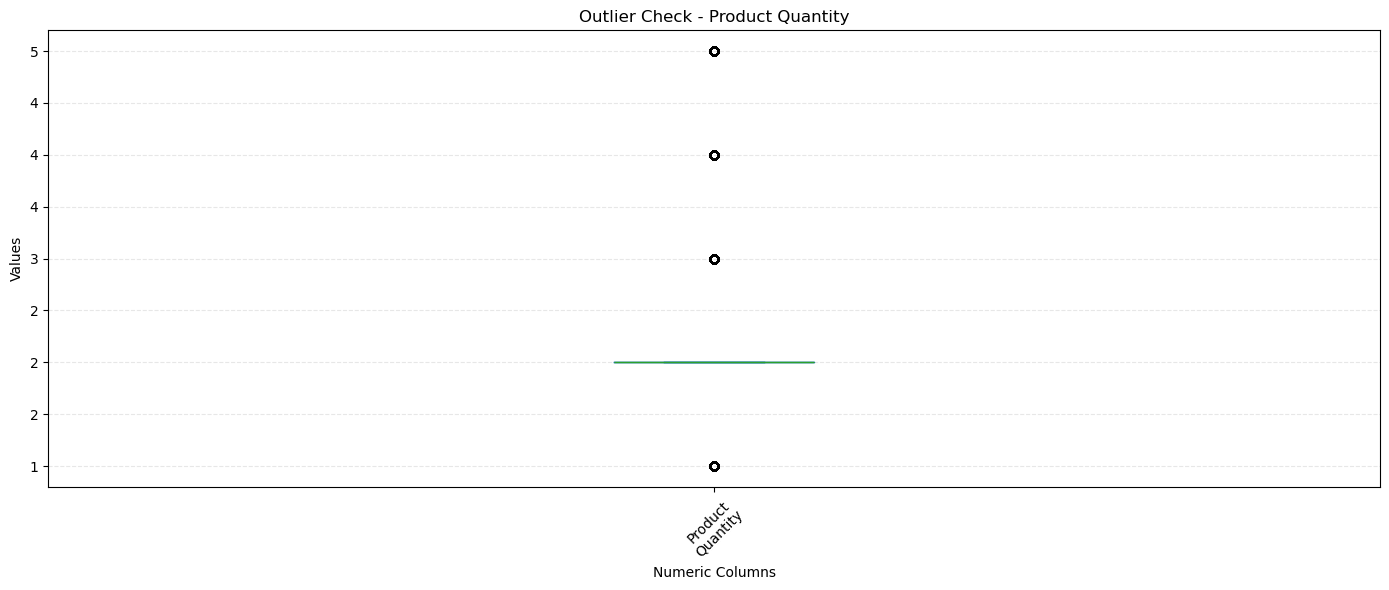

In [16]:
#Outliers check on --Product quantity
""" After removing previous outliers, data shows an extremely strong concentration at chips quantity equals to 2.
    - Any deviation from 2 (whether lower at 1, or higher at 3, 4, 5) is statistically unusual.
   - This could indicate a business model where products are typically sold in pairs
 """
fig, ax = plt.subplots(figsize=(14, 6))
(combined_df
.query('TOT_SALES <600')
 .loc[:,['PROD_QTY']]
 .rename(columns={'PROD_QTY': 'Product\nQuantity'})
 .plot
 .box(ax=ax, vert=True)
 .set(title='Outlier Check - Product Quantity',
      xlabel='Numeric Columns',
      ylabel='Values')
)

(ax.yaxis
 .set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
)

ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.tight_layout()
plt.show()

In [17]:
#The .describe() method is a meta-aggregation that returns a DataFrame containing summary statistics for all numeric columns
#Pass include ='all' to show other types and easily tell the count of the non-missing rows by inspecting count row.
(combined_df
# .describe(include = 'all')
#.PROD_QTY.value_counts()
#.query('PROD_QTY==200')
 )

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.00,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.30,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.90,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.00,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.80,MIDAGE SINGLES/COUPLES,Budget
...,...,...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.80,YOUNG SINGLES/COUPLES,Premium
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.40,YOUNG SINGLES/COUPLES,Premium
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.80,YOUNG SINGLES/COUPLES,Premium
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.80,YOUNG SINGLES/COUPLES,Premium


In [18]:
#Task here is transforming data into numeric values, categorical columns, filling in missing values and removing duplicates e.t.c.,
#We'll define a clean up function that uses pandas method chaining for this operation.
def clean_up_df(df_):
        return (df_
        .query('TOT_SALES <600') #Remove outliers in transaction data.
        #remove duplicates
        .drop_duplicates()
        .query('~PROD_NAME.str.lower().str.contains("salsa")') #remove non chpis sales
        #update dtypes
        .assign(TOT_SALES = lambda df_ : pd.to_numeric(df_.TOT_SALES),
                PROD_NAME = lambda df_: df_.PROD_NAME.astype('category'),
                LIFESTAGE = lambda df_: df_.LIFESTAGE.astype('category')
                )
        #feature engineer useful columns
        .assign(MONTH_PURCHASE = lambda df_ : df_.DATE.dt.month_name(),
                YEAR =  lambda df_ : df_.DATE.dt.year,
                #get BRAND (first word only)
                BRAND = lambda df_ : df_.PROD_NAME.str.rsplit(' ').str[0],
                PACK_SIZE_GRAMS = lambda df_ : df_.PROD_NAME
                .str.split(' ')
                .str[-1]
                .str.extract(r'(\d+)g', expand=False).fillna(0).astype(int)
                )
        #Remove invalid or corrupted transaction records, such as negative totals or zero quantity.
        .query('TOT_SALES >0 & PROD_QTY >0')
        )
#
cleaned_df = clean_up_df(combined_df)
cleaned_df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,MONTH_PURCHASE,YEAR,BRAND,PACK_SIZE_GRAMS
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.00,YOUNG SINGLES/COUPLES,Premium,October,2018,Natural,175
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.30,MIDAGE SINGLES/COUPLES,Budget,May,2019,CCs,175
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.90,MIDAGE SINGLES/COUPLES,Budget,May,2019,Smiths,170
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.00,MIDAGE SINGLES/COUPLES,Budget,August,2018,Smiths,175
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.80,MIDAGE SINGLES/COUPLES,Budget,August,2018,Kettle,150


### Exploratory Data Analysis (EDA)
My goal with EDA is to understand the data I’m dealing with by using summary statistics and visualizations. This process provides insights into what
data we have and what the data can tell us.

1. Explore purchasing behavior by:
    - Life stage
    - Premium category
    - Store
    - Product brand
    - Time (monthly sales trends)

In [19]:
#Total sales,quantity,number of transactions and average spend by life stage.
lifestage_sales  = (cleaned_df
 .groupby(['LIFESTAGE'], as_index = False,observed=True)
 .agg(TOTAL_SALES = ('TOT_SALES', 'sum'),
    TOTAL_QUANTITY = ('PROD_QTY', 'sum'),
    NUM_TRANSACTIONS = ('TXN_ID', 'nunique')
    #AVG_SPEND_PER_TXN = ('TOT_SALES','mean')
    )
 )
lifestage_sales 

,LIFESTAGE,TOTAL_SALES,TOTAL_QUANTITY,NUM_TRANSACTIONS
0,MIDAGE SINGLES/COUPLES,172523.80,44496,23259
1,NEW FAMILIES,47347.95,12070,6477
2,OLDER FAMILIES,328519.90,87896,44755
3,OLDER SINGLES/COUPLES,376013.65,97183,50506
4,RETIREES,342381.90,87875,46205
5,YOUNG FAMILIES,294627.90,78577,40190
6,YOUNG SINGLES/COUPLES,243756.60,62300,33863


In [20]:
#Most popular brands by life stage.
lifestage_brand  = (cleaned_df
.groupby(['LIFESTAGE', 'BRAND'],observed=True)
 .agg(TOTAL_QUANTITY = ('PROD_QTY', 'sum')
      )
.sort_values(['LIFESTAGE', 'TOTAL_QUANTITY'], ascending=[True, False])
.groupby('LIFESTAGE',observed=True)
.head(3)
 )
lifestage_brand 

TOTAL_QUANTITY
LIFESTAGE              BRAND                   
MIDAGE SINGLES/COUPLES Kettle              7755
                       Smiths              4785
                       Pringles            4562
NEW FAMILIES           Kettle              2191
                       Pringles            1324
                       Doritos             1203
OLDER FAMILIES         Kettle             13367
                       Smiths             10679
                       Pringles            8266
OLDER SINGLES/COUPLES  Kettle             17024
                       Smiths             10422
                       Pringles           10163
RETIREES               Kettle             15568
                       Pringles            9432
                       Smiths              9130
YOUNG FAMILIES         Kettle             12153
                       Smiths              9377
                       Pringles            7435
YOUNG SINGLES/COUPLES  Kettle             10993
                       Pringles            6837
                       Smiths              6388

In [21]:
# Pack size preference by life stage.
lifestage_packsize = (cleaned_df
.groupby(['LIFESTAGE', 'PACK_SIZE_GRAMS'],observed=True)
.agg(TOTAL_QUANTITY = ('PROD_QTY', 'sum'))
.sort_values(['LIFESTAGE', 'TOTAL_QUANTITY'], ascending=[True, False])
.groupby('LIFESTAGE',observed=True)
.head(3)
)
lifestage_packsize

TOTAL_QUANTITY
LIFESTAGE              PACK_SIZE_GRAMS                
MIDAGE SINGLES/COUPLES 175                       11782
                       150                        6925
                       134                        4562
NEW FAMILIES           175                        3150
                       150                        1882
                       134                        1324
OLDER FAMILIES         175                       23187
                       150                       13834
                       134                        8266
OLDER SINGLES/COUPLES  175                       25529
                       150                       15416
                       134                       10163
RETIREES               175                       23067
                       150                       13783
                       134                        9432
YOUNG FAMILIES         175                       20922
                       150                       12394
                       134                        7435
YOUNG SINGLES/COUPLES  175                       16053
                       150                        9584
                       134                        6837

In [22]:
#Purchasing behavior by premium category.
# Sales by premium customer type
premium_sales  = (cleaned_df
 .groupby(['PREMIUM_CUSTOMER'], as_index = False,observed=True)
 .agg(TOTAL_SALES = ('TOT_SALES', 'sum'),
    TOTAL_QUANTITY = ('PROD_QTY', 'sum'),
    NUM_TRANSACTIONS = ('TXN_ID', 'nunique'),
    NUM_CUSTOMERS = ('TXN_ID', 'nunique'))
 .assign(AVG_CUSTOMER_SPEND = lambda df_ : df_.TOTAL_SALES/df_.NUM_CUSTOMERS,
         AVG_TXN_QTY = lambda df_ : df_.TOTAL_QUANTITY/df_.NUM_TRANSACTIONS
         )
 )
premium_sales

,PREMIUM_CUSTOMER,TOTAL_SALES,TOTAL_QUANTITY,NUM_TRANSACTIONS,NUM_CUSTOMERS,AVG_CUSTOMER_SPEND,AVG_TXN_QTY
0,Budget,631406.85,165774,86197,86197,7.33,1.92
1,Mainstream,700865.40,180780,94524,94524,7.41,1.91
2,Premium,472899.45,123843,64536,64536,7.33,1.92


In [23]:
#Life stage & Premium customer cross-analysis.
lifestage_premium  = (cleaned_df
.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'],observed=True)
 .agg(TOTAL_SALES = ('TOT_SALES', 'sum'),
    TOTAL_QUANTITY = ('PROD_QTY', 'sum'),
    NUM_TRANSACTIONS = ('TXN_ID', 'nunique'))
.sort_values(['LIFESTAGE', 'TOTAL_SALES'], ascending=[True, False])
 )
lifestage_premium 

TOTAL_SALES  TOTAL_QUANTITY  \
LIFESTAGE              PREMIUM_CUSTOMER                                
MIDAGE SINGLES/COUPLES Mainstream           84734.25           21213   
                       Premium              54443.85           14400   
                       Budget               33345.70            8883   
NEW FAMILIES           Budget               20607.45            5241   
                       Mainstream           15979.70            4060   
                       Premium              10760.80            2769   
OLDER FAMILIES         Budget              156863.75           41853   
                       Mainstream           96413.55           25804   
                       Premium              75242.60           20239   
OLDER SINGLES/COUPLES  Budget              127833.60           32883   
                       Mainstream          124648.50           32607   
                       Premium             123531.55           31693   
RETIREES               Mainstream          145168.95           37677   
                       Budget              105916.30           26932   
                       Premium              91296.65           23266   
YOUNG FAMILIES         Budget              129717.95           34482   
                       Mainstream           86338.25           23194   
                       Premium              78571.70           20901   
YOUNG SINGLES/COUPLES  Mainstream          147582.20           36225   
                       Budget               57122.10           15500   
                       Premium              39052.30           10575   

                                         NUM_TRANSACTIONS  
LIFESTAGE              PREMIUM_CUSTOMER                    
MIDAGE SINGLES/COUPLES Mainstream                   11034  
                       Premium                       7564  
                       Budget                        4661  
NEW FAMILIES           Budget                        2813  
                       Mainstream                    2181  
                       Premium                       1483  
OLDER FAMILIES         Budget                       21322  
                       Mainstream                   13131  
                       Premium                      10302  
OLDER SINGLES/COUPLES  Budget                       17078  
                       Mainstream                   16958  
                       Premium                      16472  
RETIREES               Mainstream                   19878  
                       Budget                       14147  
                       Premium                      12180  
YOUNG FAMILIES         Budget                       17629  
                       Mainstream                   11860  
                       Premium                      10701  
YOUNG SINGLES/COUPLES  Mainstream                   19482  
                       Budget                        8547  
                       Premium                       5834

In [24]:
#Store performance top ten  (10).
top_performing_stores  = (cleaned_df
 .groupby('STORE_NBR',as_index = False,observed=True)
  .agg(TOTAL_SALES = ('TOT_SALES', 'sum'),
    TOTAL_QUANTITY = ('PROD_QTY', 'sum'),
    NUM_TRANSACTIONS = ('TXN_ID', 'nunique'),
    NUM_CUSTOMERS = ('LYLTY_CARD_NBR', 'nunique')
    )
.assign(AVG_TXN_VALUE = lambda df_ : df_.TOTAL_SALES/df_.NUM_TRANSACTIONS)
.nlargest(10, 'TOTAL_SALES')
.reset_index(drop = True)
 )
top_performing_stores 

,STORE_NBR,TOTAL_SALES,TOTAL_QUANTITY,NUM_TRANSACTIONS,NUM_CUSTOMERS,AVG_TXN_VALUE
0,226,16544.65,3793,1905,381,8.68
1,88,15445.85,3544,1771,387,8.72
2,165,15188.35,3448,1728,390,8.79
3,237,14830.60,3376,1702,380,8.71
4,40,14427.30,3277,1645,387,8.77
5,58,14256.95,3268,1629,390,8.75
6,199,13975.90,3182,1590,376,8.79
7,4,13709.25,3132,1576,378,8.70
8,203,13623.40,3105,1559,395,8.74
9,26,13597.20,3085,1546,375,8.80


In [25]:
#Store performance bottom ten.
bottom_performing_stores  = (cleaned_df
 .groupby('STORE_NBR',as_index = False,observed=True)
  .agg(TOTAL_SALES = ('TOT_SALES', 'sum'),
    TOTAL_QUANTITY = ('PROD_QTY', 'sum'),
    NUM_TRANSACTIONS = ('TXN_ID', 'nunique'),
    NUM_CUSTOMERS = ('LYLTY_CARD_NBR', 'nunique')
    )
.assign(AVG_TXN_VALUE = lambda df_ : df_.TOTAL_SALES/df_.NUM_TRANSACTIONS)
.nsmallest(10, 'TOTAL_SALES')
.reset_index(drop = True)
 )
bottom_performing_stores 

,STORE_NBR,TOTAL_SALES,TOTAL_QUANTITY,NUM_TRANSACTIONS,NUM_CUSTOMERS,AVG_TXN_VALUE
0,76,6.00,2,1,1,6.00
1,11,6.70,2,2,2,3.35
2,252,7.40,2,2,2,3.70
3,206,7.60,2,2,2,3.80
4,92,9.20,2,1,1,9.20
5,85,10.90,3,2,2,5.45
6,193,13.10,4,3,3,4.37
7,31,14.80,4,2,2,7.40
8,117,144.90,42,41,40,3.53
9,177,191.80,54,51,48,3.76


In [26]:
#Purchasing Behaviour by brand.
# Brand performance top 10.
brand_sales  = (cleaned_df
.groupby('BRAND',as_index = False,observed=True)
  .agg(TOTAL_SALES = ('TOT_SALES', 'sum'),
    TOTAL_QUANTITY = ('PROD_QTY', 'sum'),
    NUM_TRANSACTIONS = ('TXN_ID', 'nunique'),
    NUM_CUSTOMERS = ('LYLTY_CARD_NBR', 'nunique'))
 .assign(AVG_PRICE_PER_UNIT=lambda df_: df_.TOTAL_SALES / df_.TOTAL_QUANTITY,
         AVG_TRANSACTION_VALUE=lambda df_: df_.TOTAL_SALES / df_.NUM_TRANSACTIONS,
        AVG_SPEND_PER_CUSTOMER=lambda df_: df_.TOTAL_SALES / df_.NUM_CUSTOMERS,
        MARKET_SHARE_PCT=lambda df_: (df_.TOTAL_SALES / df_.TOTAL_SALES.sum()) * 100)
.sort_values('TOTAL_SALES', ascending=False)
.reset_index(drop=True)
#.MARKET_SHARE_PCT.sum()
.nlargest(10, 'TOTAL_SALES')
)
brand_sales

,BRAND,TOTAL_SALES,TOTAL_QUANTITY,NUM_TRANSACTIONS,NUM_CUSTOMERS,AVG_PRICE_PER_UNIT,AVG_TRANSACTION_VALUE,AVG_SPEND_PER_CUSTOMER,MARKET_SHARE_PCT
0,Kettle,390239.80,79051,41257,30176,4.94,9.46,12.93,21.62
1,Smiths,202902.60,51971,27367,20936,3.90,7.41,9.69,11.24
2,Doritos,187277.90,42222,22026,18521,4.44,8.50,10.11,10.37
3,Pringles,177655.50,48019,25093,20657,3.70,7.08,8.60,9.84
4,Thins,88852.50,26929,14072,12591,3.30,6.31,7.06,4.92
5,Twisties,81522.10,18118,9451,8729,4.50,8.63,9.34,4.52
6,Tostitos,79789.60,18134,9469,8760,4.40,8.43,9.11,4.42
7,Infuzions,76247.60,21119,11056,10085,3.61,6.90,7.56,4.22
8,Cobs,70569.80,18571,9692,8964,3.80,7.28,7.87,3.91
9,RRD,64954.50,22500,11887,9953,2.89,5.46,6.53,3.60


In [27]:
#Brand preference by customer segment. 
brand_by_segment = (cleaned_df
 .groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER', 'BRAND'],observed=True)
 .agg(TOTAL_SALES = ('TOT_SALES', 'sum'))
)
brand_by_segment


TOTAL_SALES
LIFESTAGE              PREMIUM_CUSTOMER BRAND                  
MIDAGE SINGLES/COUPLES Budget           Burger           193.20
                                        CCs              430.50
                                        Cheetos          337.60
                                        Cheezels         612.30
                                        Cobs            1311.00
...                                                         ...
YOUNG SINGLES/COUPLES  Premium          Tostitos        1698.40
                                        Twisties        1619.00
                                        Tyrrells         991.20
                                        WW              1105.90
                                        Woolworths       163.80

[588 rows x 1 columns]

In [28]:
#Time Series Analysis (Monthly Sales Trend)
#Monthly sales trends
monthly_sales = (cleaned_df
    .groupby(['YEAR', 'MONTH_PURCHASE'], as_index=False, observed=True)
    .agg(TOTAL_SALES = ('TOT_SALES', 'sum'),
        PROD_QTY = ('PROD_QTY', 'sum'),
        NUMBER_TRANSACTIONS = ('TXN_ID', 'nunique')
        )
    .assign(AVG_TXN_VALUE = lambda df_: df_.TOTAL_SALES / df_.NUMBER_TRANSACTIONS)
)
monthly_sales

,YEAR,MONTH_PURCHASE,TOTAL_SALES,PROD_QTY,NUMBER_TRANSACTIONS,AVG_TXN_VALUE
0,2018,August,147422.05,38481,20739,7.11
1,2018,December,156461.60,40778,21090,7.42
2,2018,July,154514.50,40310,20906,7.39
3,2018,November,149609.50,39045,20228,7.40
4,2018,October,153448.10,39909,20657,7.43
5,2018,September,150058.90,39001,20165,7.44
6,2019,April,149374.20,38980,20164,7.41
7,2019,February,140480.00,36541,18878,7.44
8,2019,January,151593.80,39519,20474,7.40
9,2019,June,150135.90,39042,20260,7.41


In [29]:
## Customer segementation analysis
# Customer purchase frequency and value - high value customers
customer_metrics = (cleaned_df
    .groupby('LYLTY_CARD_NBR', as_index=False, observed=True)
    .agg(NUM_TRANSACTIONS =('TXN_ID', 'nunique'),
        TOTAL_SALES =('TOT_SALES', 'sum'),
        TOTAL_QTY =('PROD_QTY', 'sum'),
        FIRST_PURCHASE =('DATE', 'min'),
        LAST_PURCHASE =('DATE', 'max')
    )
    .assign(AVG_SPEND_PER_VISIT =lambda df_: df_.TOTAL_SALES / df_.NUM_TRANSACTIONS,
        DAYS_ACTIVE = lambda df_: (df_.LAST_PURCHASE - df_.FIRST_PURCHASE).dt.days + 1,
        PURCHASE_FREQUENCY =lambda df_: df_.NUM_TRANSACTIONS / (df_.DAYS_ACTIVE / 30))
    .nlargest(100, 'TOTAL_SALES')
    .reset_index(drop =True)
)
customer_metrics

,LYLTY_CARD_NBR,NUM_TRANSACTIONS,TOTAL_SALES,TOTAL_QTY,FIRST_PURCHASE,LAST_PURCHASE,AVG_SPEND_PER_VISIT,DAYS_ACTIVE,PURCHASE_FREQUENCY
0,230078,17,138.60,36,2018-07-18,2019-06-20,8.15,338,1.51
1,58361,12,124.80,28,2018-08-10,2019-06-25,10.40,320,1.12
2,63197,14,122.60,30,2018-07-09,2019-06-23,8.76,350,1.20
3,162039,17,121.60,34,2018-08-09,2019-06-21,7.15,317,1.61
4,179228,16,120.80,32,2018-07-04,2019-06-28,7.55,360,1.33
...,...,...,...,...,...,...,...,...,...
95,128092,13,97.60,26,2018-08-25,2019-06-21,7.51,301,1.30
96,160209,12,97.50,23,2018-08-22,2019-05-28,8.12,280,1.29
97,94137,12,97.00,24,2018-07-14,2019-06-11,8.08,333,1.08
98,184199,12,97.00,26,2018-07-31,2019-06-26,8.08,331,1.09


In [30]:
#Packsize Analysis - Pack size preference
packsize_sales = (cleaned_df
    .assign()
    .groupby('PACK_SIZE_GRAMS', as_index=False, observed=True)
    .agg(TOTAL_SALES = ('TOT_SALES', 'sum'),
        TOTAL_QTY = ('PROD_QTY', 'sum'),
        NUM_TRANSACTIONS = ('TXN_ID', 'nunique'))
    #Handle zero divisor using where clause
   .assign(AVG_PRICE_PER_GRAM=lambda df_: np.where(df_.PACK_SIZE_GRAMS == 0,np.nan,df_.TOTAL_SALES / (df_.TOTAL_QTY * df_.PACK_SIZE_GRAMS)))
   .sort_values('TOTAL_SALES', ascending=False)
   .reset_index(drop = True)
)
packsize_sales

,PACK_SIZE_GRAMS,TOTAL_SALES,TOTAL_QTY,NUM_TRANSACTIONS,AVG_PRICE_PER_GRAM
0,175,477106.40,123690,64834,0.02
1,150,282003.00,73818,38678,0.03
2,134,177655.50,48019,25093,0.03
3,110,162765.40,42835,22378,0.03
4,170,146673.00,38088,19969,0.02
5,330,136794.30,23999,12536,0.02
6,165,101360.60,29051,15290,0.02
7,380,75419.60,12273,6415,0.02
8,0,63442.20,17762,9319,NaN
9,270,55425.40,12049,6285,0.02


In [31]:
# Product Analysis - Top 20 selling products
top_products = (cleaned_df
    .groupby('PROD_NAME', as_index=False, observed=True)
    .agg(TOTAL_SALES = ('TOT_SALES', 'sum'),
        TOTAL_QTY = ('PROD_QTY', 'sum'),
        NUM_TRANSACTIONS = ('TXN_ID', 'nunique')
    )
    .nlargest(20, 'TOTAL_SALES')
    .reset_index(drop =True)
)
top_products

,PROD_NAME,TOTAL_SALES,TOTAL_QTY,NUM_TRANSACTIONS
0,Dorito Corn Chp Supreme 380g,39052.00,6109,3183
1,Smiths Crnkle Chip Orgnl Big Bag 380g,36367.60,6164,3233
2,Smiths Crinkle Chips Salt & Vinegar 330g,34804.20,6106,3197
3,Kettle Mozzarella Basil & Pesto 175g,34457.40,6381,3304
4,Smiths Crinkle Original 330g,34302.60,6018,3142
5,Cheezels Cheese 330g,34296.90,6017,3149
6,Doritos Cheese Supreme 330g,33390.60,5858,3052
7,Kettle Sweet Chilli And Sour Cream 175g,33031.80,6120,3200
8,Kettle Original 175g,32740.20,6064,3159
9,Kettle Sea Salt And Vinegar 175g,32589.00,6035,3173


In [32]:
#Cross segement analysis
# Most valuable customer segments -Life Stage & Premium Customer analysis
segment_value = (cleaned_df
    .groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'], as_index=False, observed=True)
    .agg(TOTAL_SALES = ('TOT_SALES', 'sum'),
        NUM_CUSTOMERS = ('LYLTY_CARD_NBR', 'nunique'),
        NUM_TRANSACTIONS = ('TXN_ID', 'nunique'))
    .assign(AVG_SPEND_PER_CUSTOMER =lambda df_: df_.TOTAL_SALES / df_.NUM_CUSTOMERS,
        SALES_CONTRIBUTION_PCT =lambda df_: (df_.TOTAL_SALES / df_.TOTAL_SALES.sum()) * 100 )
    .sort_values(by=['TOTAL_SALES'], ascending=False)
)
segment_value

,LIFESTAGE,PREMIUM_CUSTOMER,TOTAL_SALES,NUM_CUSTOMERS,NUM_TRANSACTIONS,AVG_SPEND_PER_CUSTOMER,SALES_CONTRIBUTION_PCT
6,OLDER FAMILIES,Budget,156863.75,4611,21322,34.02,8.69
19,YOUNG SINGLES/COUPLES,Mainstream,147582.20,7917,19482,18.64,8.18
13,RETIREES,Mainstream,145168.95,6358,19878,22.83,8.04
15,YOUNG FAMILIES,Budget,129717.95,3953,17629,32.82,7.19
9,OLDER SINGLES/COUPLES,Budget,127833.60,4849,17078,26.36,7.08
10,OLDER SINGLES/COUPLES,Mainstream,124648.50,4858,16958,25.66,6.91
11,OLDER SINGLES/COUPLES,Premium,123531.55,4682,16472,26.38,6.84
12,RETIREES,Budget,105916.30,4385,14147,24.15,5.87
7,OLDER FAMILIES,Mainstream,96413.55,2788,13131,34.58,5.34
14,RETIREES,Premium,91296.65,3812,12180,23.95,5.06


In [33]:
#Customer Segment Analysis
segment_sales = (cleaned_df
 .groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'], as_index=False, observed=True)
 .agg(Total_Sales=('TOT_SALES', 'sum'))
 .pivot(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='Total_Sales')
 .fillna(0)
 .style
.background_gradient(cmap='RdBu', vmax=1, vmin=-1)
.format('{:,.2f}')
.set_sticky(axis='index')
)
segment_sales

PREMIUM_CUSTOMER,Budget,Mainstream,Premium
LIFESTAGE,,,
MIDAGE SINGLES/COUPLES,"33,345.70","84,734.25","54,443.85"
NEW FAMILIES,"20,607.45","15,979.70","10,760.80"
OLDER FAMILIES,"156,863.75","96,413.55","75,242.60"
OLDER SINGLES/COUPLES,"127,833.60","124,648.50","123,531.55"
RETIREES,"105,916.30","145,168.95","91,296.65"
YOUNG FAMILIES,"129,717.95","86,338.25","78,571.70"
YOUNG SINGLES/COUPLES,"57,122.10","147,582.20","39,052.30"


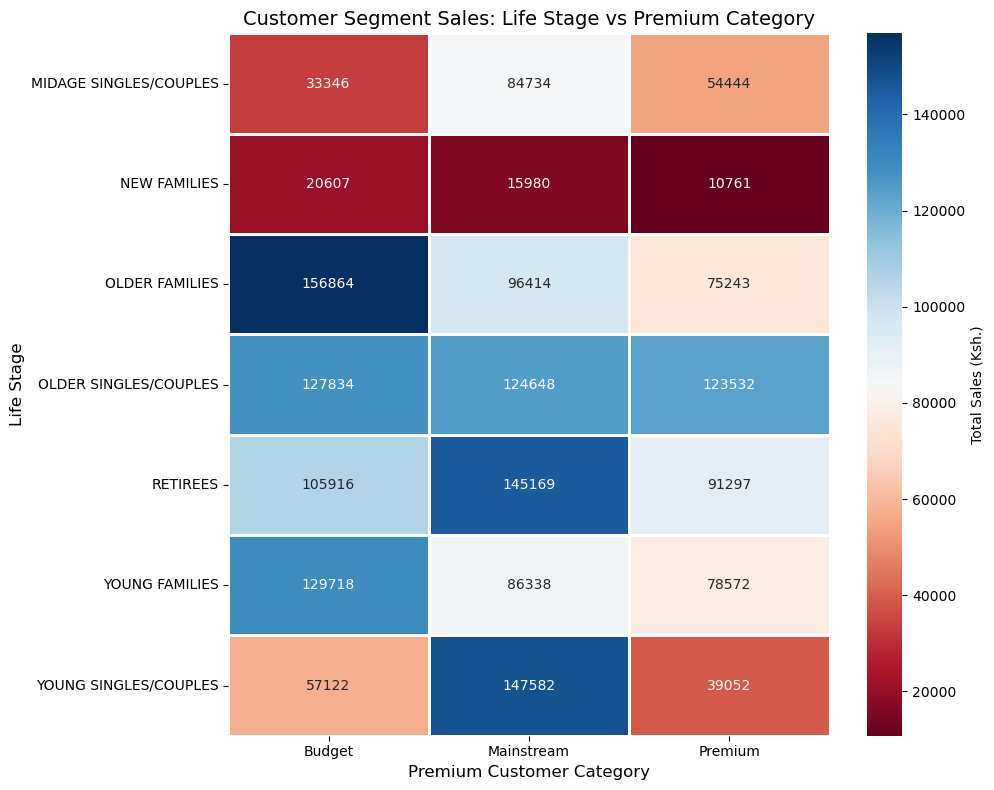

In [34]:
#Create visualizations
# Customer Segment Analysis Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap((cleaned_df
            .groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'], as_index=False, observed=True)
            .agg(Total_Sales=('TOT_SALES', 'sum'))
            .pivot(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='Total_Sales')
            .fillna(0)), 
            annot=True, 
            fmt='.0f', 
            cmap='RdBu', 
            linewidths=1, 
            cbar_kws={'label': 'Total Sales (Ksh.)'},
            ax=ax)
ax.set_title('Customer Segment Sales: Life Stage vs Premium Category', fontsize=14)
ax.set_xlabel('Premium Customer Category', fontsize=12)
ax.set_ylabel('Life Stage', fontsize=12)
plt.tight_layout()
plt.show()

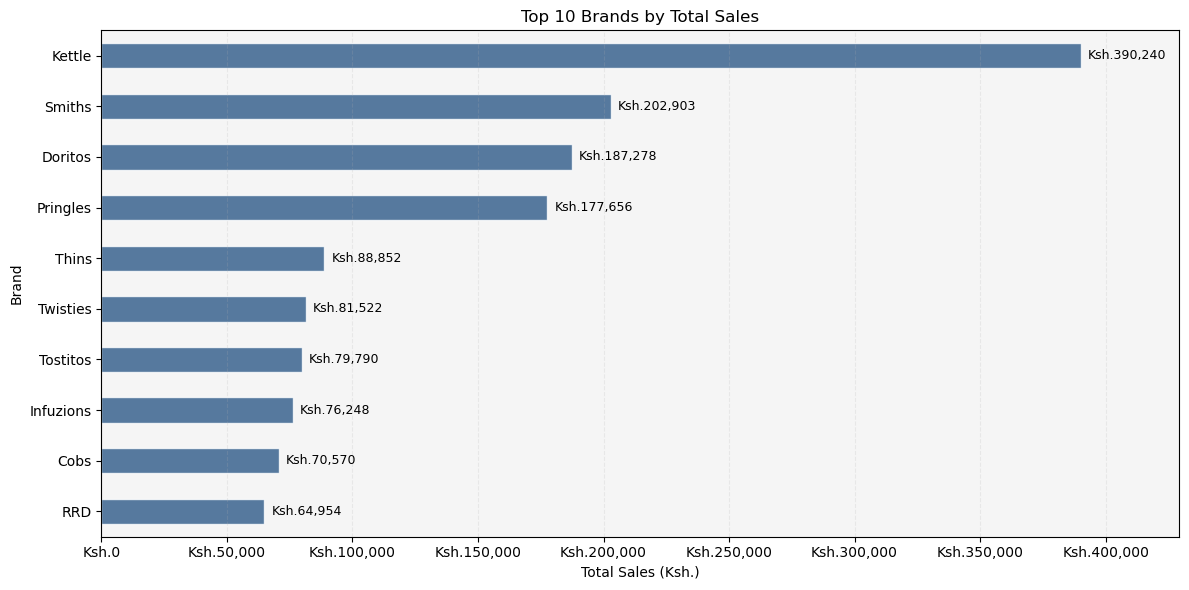

In [35]:
#Top ten brands by total sales (Horizontal Bar Chart).
#=========================
#basic plotting colors configs
BLUE = '#2E5A88'    
GRAY = '#7B8B8E'  
GREEN = '#5A8C5A' 
LIGHT_GRAY = '#F5F5F5'
#==========================

fig, ax = plt.subplots(figsize=(12, 6))
(brand_sales
 .sort_values('TOTAL_SALES', ascending=True)
 .set_index('BRAND')
 .TOTAL_SALES
 .plot
 .barh(ax=ax, 
       color=BLUE,
       edgecolor='white',
       linewidth=1,
       alpha=0.8)
 .set(title='Top 10 Brands by Total Sales', 
      xlabel='Total Sales (Ksh.)', 
      ylabel='Brand',
      xlim=(0, brand_sales['TOTAL_SALES'].max() * 1.1))
)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'Ksh.{x:,.0f}'))

for container in ax.containers:
    ax.bar_label(container, 
                 fmt=lambda x: f'Ksh.{x:,.0f}', 
                 padding=5, 
                 fontsize=9,
                 color='black')

ax.set_facecolor(LIGHT_GRAY)
ax.grid(True, axis='x', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

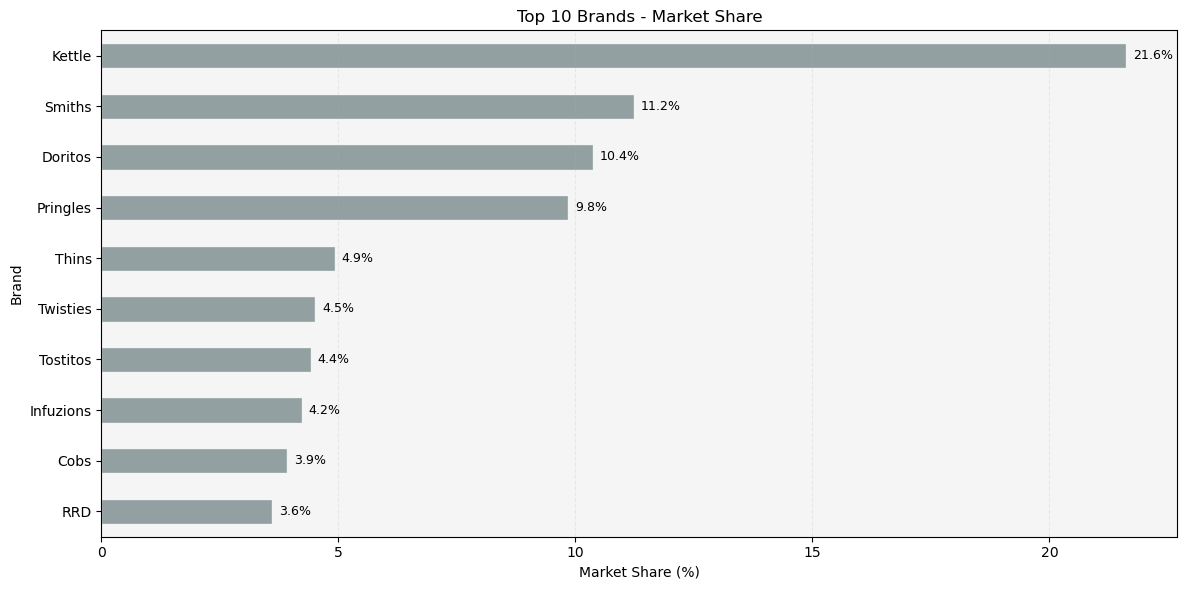

In [36]:
#Market Share Distribution

fig, ax = plt.subplots(figsize=(12, 6))
(brand_sales
 .sort_values('MARKET_SHARE_PCT', ascending=True)
 .set_index('BRAND')
 .MARKET_SHARE_PCT
 .plot
 .barh(ax=ax, 
       color=GRAY,
       edgecolor='white',
       linewidth=1,
       alpha=0.8)
 .set(title='Top 10 Brands - Market Share', 
      xlabel='Market Share (%)', 
      ylabel='Brand')
)

for container in ax.containers:
    ax.bar_label(container, 
                 fmt=lambda x: f'{x:.1f}%', 
                 padding=5, 
                 fontsize=9,
                 color='black')

ax.set_facecolor(LIGHT_GRAY)
ax.grid(True, axis='x', alpha=0.2, linestyle='--')
plt.tight_layout()
plt.show()

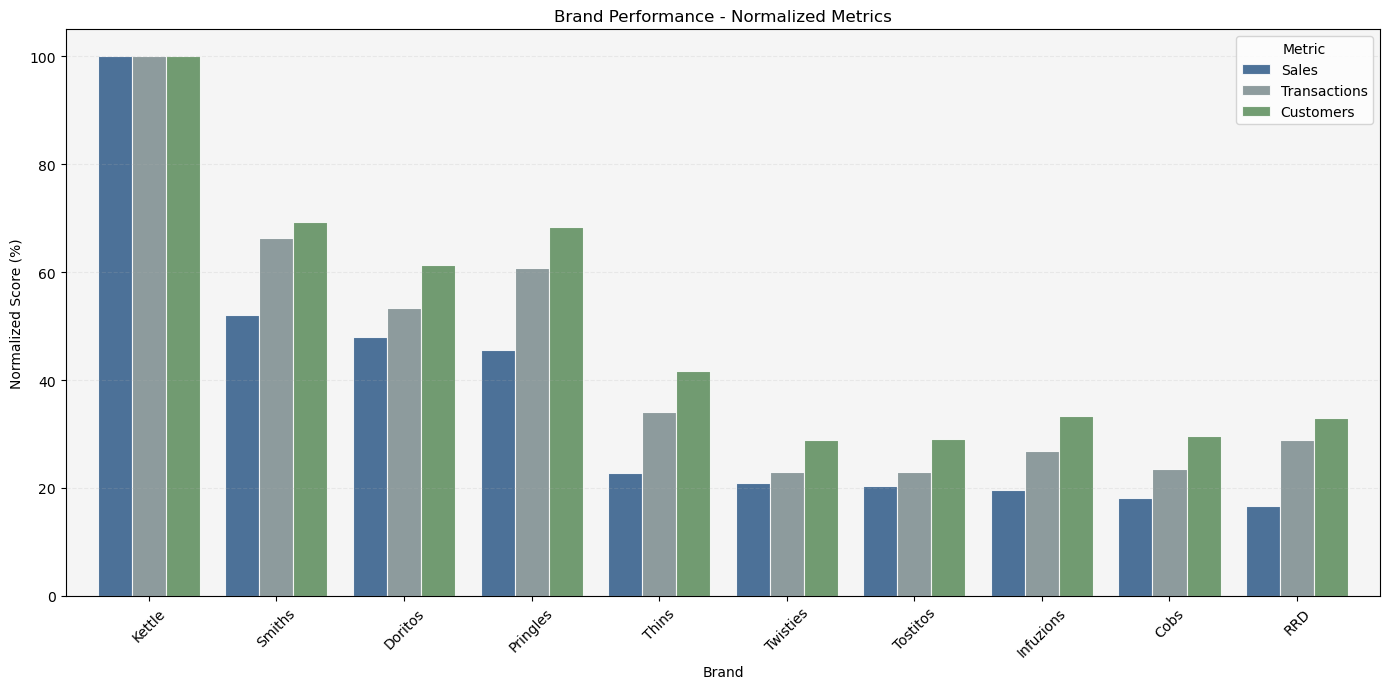

In [37]:
# Multi metric comparison - Grouped Bar Chart
fig, ax = plt.subplots(figsize=(14, 7))
(brand_sales
 .set_index('BRAND')
 .loc[:,['TOTAL_SALES', 'NUM_TRANSACTIONS', 'NUM_CUSTOMERS']]
 .apply(lambda df_: df_ / df_.max() * 100)
 .plot
 .bar(ax=ax, 
      width=0.8,
      color=[BLUE, GRAY, GREEN],
      edgecolor='white',
      linewidth=0.8,
      alpha=0.85)
 .set(title='Brand Performance - Normalized Metrics',
      xlabel='Brand',
      ylabel='Normalized Score (%)',
      ylim=(0, 105))
)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax.tick_params(axis='x', rotation=45)
ax.legend(['Sales', 'Transactions', 'Customers'], title='Metric', loc='upper right')
ax.set_facecolor(LIGHT_GRAY)
ax.grid(True, axis='y', alpha=0.2, linestyle='--')
plt.tight_layout()
plt.show()

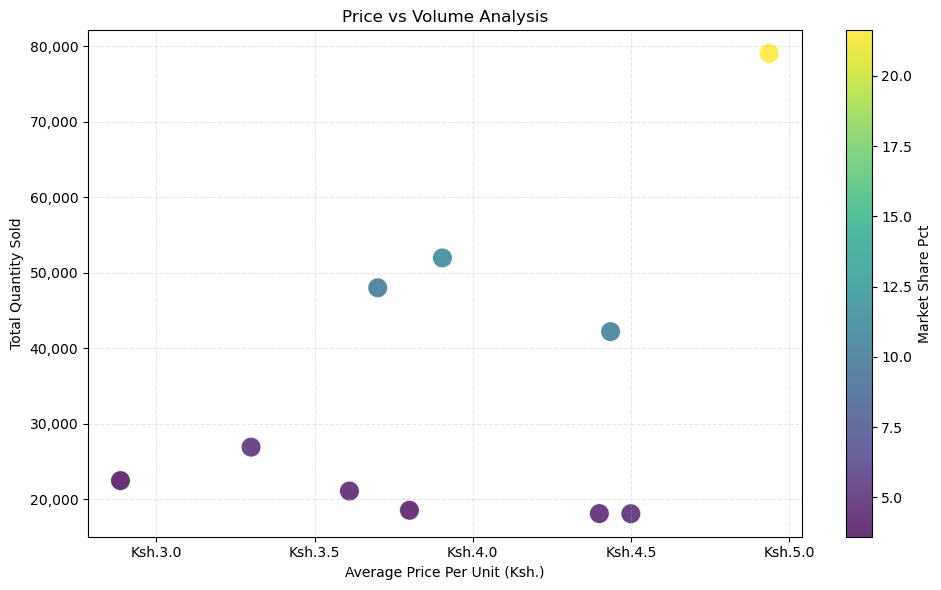

In [38]:
# Price vs Volume Analysis - Scatter 
fig, ax = plt.subplots(figsize=(10, 6))
scatter = (brand_sales
 .rename(columns = {'MARKET_SHARE_PCT': 'Market Share Pct'})
 .plot.scatter(x='AVG_PRICE_PER_UNIT', 
               y='TOTAL_QUANTITY', 
               alpha=0.8, 
               ax=ax, 
               c='Market Share Pct',
               cmap='viridis',
               s=200,
               edgecolors='white',
               linewidth=0.5)
 .set(title='Price vs Volume Analysis',
      xlabel='Average Price Per Unit (Ksh.)',
      ylabel='Total Quantity Sold')
)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'Ksh.{x:,.1f}'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

**Key findings & strategic recommendations**
1.	**Market Share** - Kettle is the undisputed market leader that has captured 21.6% share and nearly doubling the sales of the next competitor (Smiths).

    **Recommendation**:

	> Kettle's Premium Volume Strategy is highly effective and must be sustained.
2.	Customer Value - Mid-age Singles/Couples and Older Singles/Couples are the highest revenue segments and should be prioritized.

    **Recommendation**:

	> Marketing efforts should focus on maintaining engagement with these mature and established demographics.
3.	Brand Efficiency - Lower-tier brands show critical efficiency gaps. Their customer base and transaction volume significantly exceed their sales contribution.

    **Recommendation**:

	> Struggling brands must urgently address low average transaction value through premiumization, product bundling, or portfolio optimization.
4.	Market Structure - The Top 4 brands control 53% of the market with clear tiering between the premium leader (Kettle), competitive mid-market (Smiths, Doritos, Pringles) and fragmented lower tiers.

    **Recommendation**:

	> Opportunities exist for mid-tier brands to improve transaction value and capture market share from the efficiency poor lower tiers.

